<img src="https://assets-datascientest.s3-eu-west-1.amazonaws.com/train/logo_datascientest.png" style="height:150px">

<hr style="border-width:2px;border-color:#75DFC1">

<center><h1> ORT : Modèle ARIMA </h1></center>

<hr style="border-width:2px;border-color:#75DFC1">

> Nous proposons ici une première analyse réalisée dans des délais urgents pour notre commanditaire.
> 
> Pour cette première étape, compte tenu des informations partielles que nous avons, nous nous concentrons sur **l’évolution de la couverture coralienne** pour **chacun de quatre types de coraux** au sein **d’une couverture récifale spécifique**.
>
> Cette analyse sera réalisée en utilisant **quatre modèles indépendants**, chacun permettant d’explorer la dynamique de ces formations coralliennes.
>
> Nous présenterons deux approches de modélisation :
>
> - **Modélisation à court terme** : cette approche vise à prédire la couverture des coraux à l’année *t* à partir des informations disponibles à *t−1*.
> - **Modélisation à moyen terme** : cette approche permettra de réaliser des prédictions pour les années *t+1*, *t+2*, *t+3* et *t+4* en utilisant uniquement les données disponibles à l’année *t*.
>
> Techniquement, ces deux solutions correspondent respectivement à ce que l’on appelle modèles **autoregressifs à pas simple** et **modèles autoregressifs multi-pas**.
>
> Dans ce notebook, nous commencerons par importer les bibliothèques nécessaires et la donnée. Nous effectuerons également un prétraitement simple en remplaçant les valeurs manquantes codées par -999 par des `NaN` pour faciliter l’analyse.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/GBR_ltmp.csv')

df.replace({-999 : np.nan, '-999' : np.nan}, inplace = True)

df.isna().sum().sort_values(ascending = False)

HC_1             4037
HERB2            3527
DISTURBANCE      3377
COVER            3352
DISEASE          3347
D                3347
HC               3347
STORM            3347
COTS             3347
B                3347
BLEACHING        3347
S                3347
C                3337
HERB             1380
LAT                 0
A_SECTOR            0
REEF_NAME           0
REEF_ID             0
SHELF               0
TRANSECT_NO         0
REPORT_YEAR         0
SITE_NO             0
SITE_LON            0
LON                 0
SITE_LAT            0
AREA                0
CONNECTEDNESS       0
BENT_CLUST          0
CLUSTER             0
RST                 0
RSTY                0
iZONE               0
sZONE               0
PFp                 0
PFs                 0
PFt                 0
PFsum               0
dtype: int64

> Compte tenu des problèmes liés aux valeurs manquantes, nous adoptons dans un premier temps une approche prudente.
> 
> Nous concentrons notre analyse sur la couverture corallienne à l’échelle de chaque plateau récifal, ce qui nous permet de disposer d’une base fiable malgré les données incomplètes.
>
> L’objectif principal est d’estimer l’évolution de la couverture corallienne sur l’ensemble d’une plateforme récifale.
>
> Pour **prioriser** notre travail, nous commençons par visualiser comment la couverture varie selon le type de corail à travers les différents plateaux récifaux. Ces visualisations permettront de mettre en évidence les tendances principales et d’orienter les étapes suivantes de l’analyse. Elles nous aideront également à décider par quel plateau récifal commencer nos investigations plus détaillées.

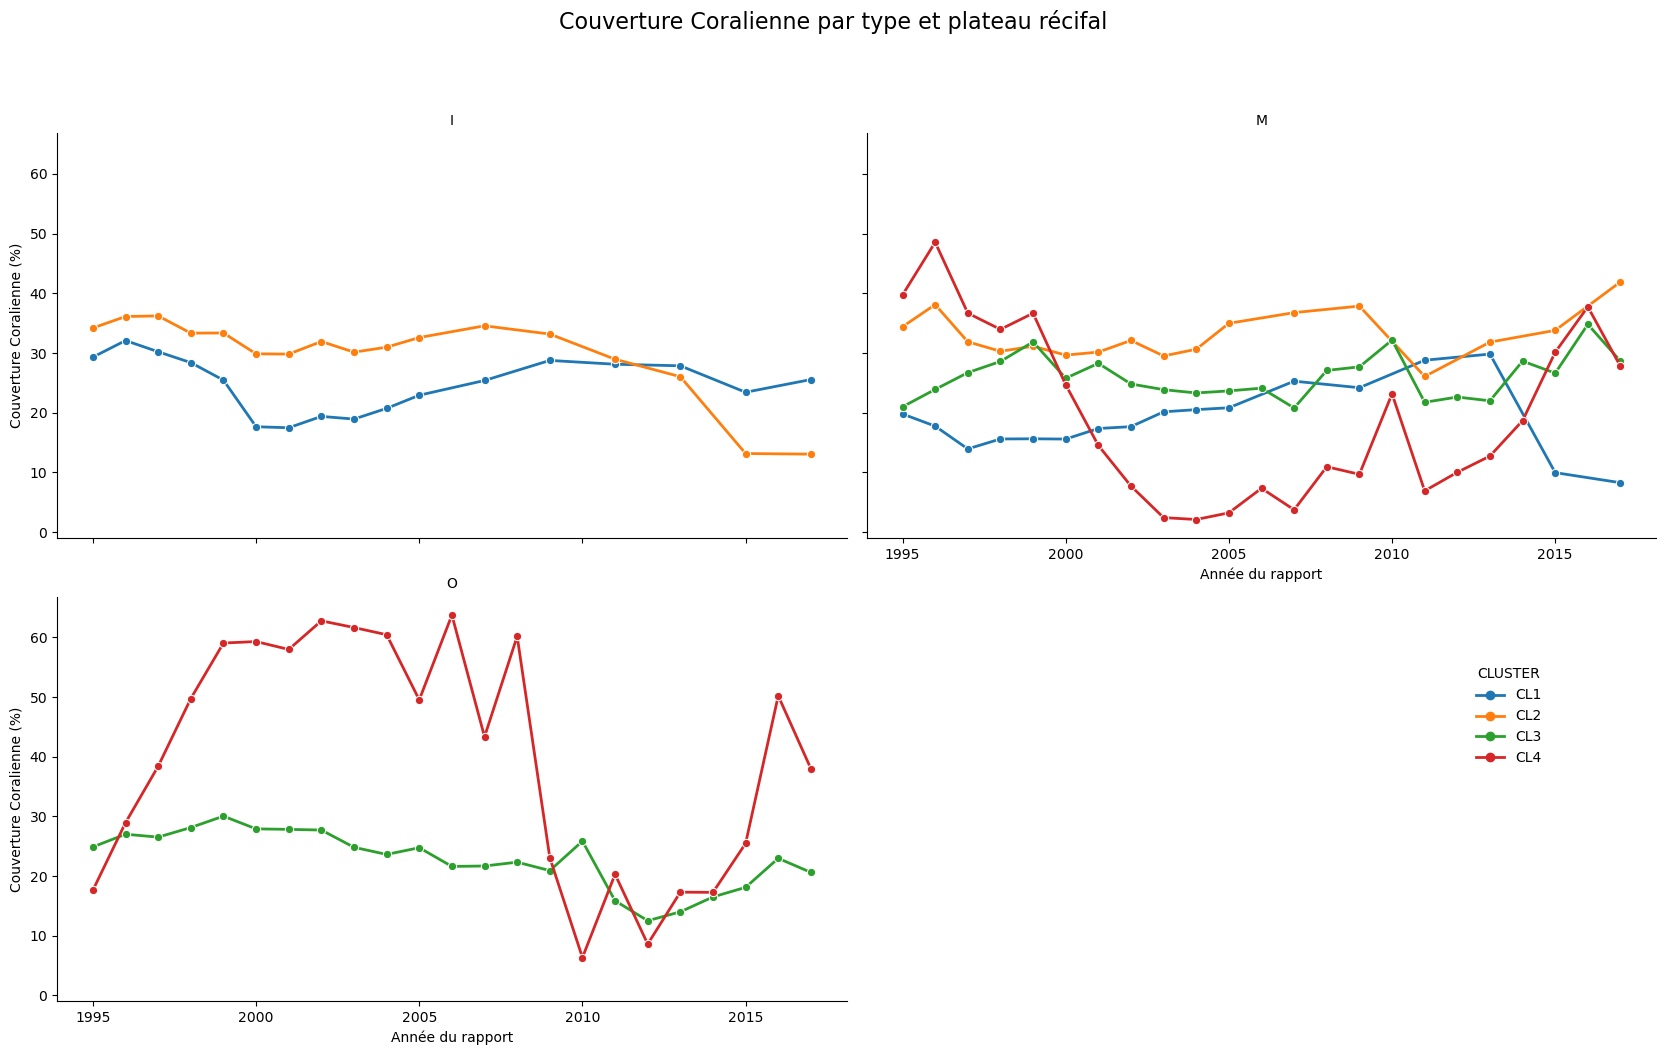

In [2]:
data = df.groupby(['SHELF', 'CLUSTER', 'REPORT_YEAR'])['HC'].mean().reset_index()

g = sns.relplot(
    x='REPORT_YEAR',
    y='HC',
    hue='CLUSTER',
    kind='line',            
    data=data,
    col='SHELF',
    col_wrap=2,             
    height=5,               
    aspect=1.6,            
    marker='o',             
    linewidth=2
)

g.fig.suptitle('Couverture Coralienne par type et plateau récifal', fontsize=16, y=1.05)

g.set_axis_labels('Année du rapport', 'Couverture Coralienne (%)')
g.set_titles('{col_name}')  

g._legend.set_bbox_to_anchor((0.9, 0.4)) 
g._legend.set_loc('upper center')
g._legend.set_frame_on(False) 

plt.tight_layout()
plt.show()

> Compte tenu de ces résultats, nous établissons cette première stratégie. Nous concentrons notre analyse sur le **plateau récifal M**, car c’est ici que nous disposons de **l’ensemble des quatre types de coraux** (`CLUSTER`).
>
> Pour chaque type de corail sur ce plateau, nous allons créer un **modèle indépendant**, soit quatre modèles linéaires distincts. Chaque modèle sera évalué selon deux approches :
>
> - **Modélisation à court terme** : cette approche vise à prédire la couverture des coraux à l’année *t* à partir des informations disponibles à *t−1*.
> - **Modélisation à moyen terme** : cette approche permettra de réaliser des prédictions pour les années *t+1*, *t+2*, *t+3* et *t+4* en utilisant uniquement les données disponibles à l’année *t*.
>
> Nous commencerons par importer les bibliothèques nécessaires pour le traitement des données et la modélisation. Ensuite, nous sélectionnerons les valeurs correspondant au **cluster 4** dans le plateau récifal **M**.
>
> Pour cette première analyse, nous **agrégeons toutes les mesures à travers l’ensemble des sites et transects du plateau**, ce qui entraîne une perte d’information. Nous aborderons plus tard cette problématique en utilisant des modèles plus performants et sophistiqués pour capturer les variations fines.

In [3]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

shelf_m = df.loc[(df['SHELF'] == 'M') & (df['CLUSTER'] == 'CL4')].groupby('REPORT_YEAR')['HC'].mean().reset_index()

shelf_m

,REPORT_YEAR,HC
0,1995,39.735667
1,1996,48.564000
2,1997,36.684333
3,1998,33.961000
4,1999,36.668333
5,2000,24.688000
6,2001,14.515333
7,2002,7.707000
8,2003,2.420333
9,2004,2.104000


> Visualisons maintenant l’évolution temporelle de la couverture du cluster CL4 sur le plateau récifal M.

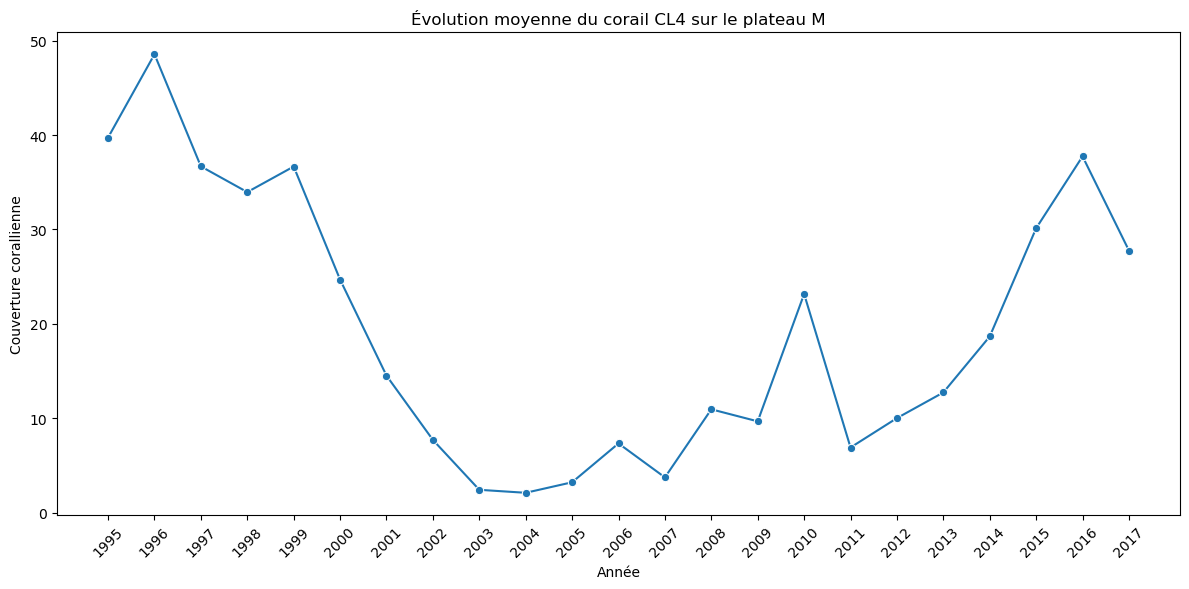

In [4]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=shelf_m,
    x='REPORT_YEAR',
    y='HC',
    marker='o'
)

years = sorted(shelf_m['REPORT_YEAR'].unique())
ax.set_xticks(years)

plt.xticks(rotation=45)  
plt.xlabel("Année")
plt.ylabel("Couverture corallienne")
plt.title("Évolution moyenne du corail CL4 sur le plateau M")

plt.tight_layout()
plt.show()

> Notre série ne présente pas de motif clair, ni de tendance évidente, ni de saisonnalité marquée.
>
> Vérifions d’abord si la série est stationnaire. Dans le cas contraire, nous envisagerons de différencier la série afin de la rendre stationnaire, en testant différents ordres de différenciation compris entre 1 et 3.

In [5]:
ts = shelf_m.copy()
ts['REPORT_YEAR'] = pd.to_datetime(ts['REPORT_YEAR'], format='%Y')
ts = ts.set_index('REPORT_YEAR')
ts = ts.asfreq('YS') 

ordres = np.arange(1, 4)

for ordre in ordres:

    diff_series = ts['HC'].diff(ordre).dropna()
    
    result = adfuller(diff_series)
    
    # Affichage des résultats
    print(f"Ordre de différenciation : {ordre}")
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value : {result[1]:.4f}\n")
    

Ordre de différenciation : 1
ADF statistic : -4.7505
p-value : 0.0001

Ordre de différenciation : 2
ADF statistic : -2.2890
p-value : 0.1755

Ordre de différenciation : 3
ADF statistic : -0.4016
p-value : 0.9098



> Nous avons déterminé que l’ordre de différenciation optimal pour notre série temporelle est **1**, ce qui permet de rendre la série stationnaire. La série est donc désormais différenciée.
>
> Nous pouvons maintenant chercher les ordres appropriés pour les composantes AR (Auto-Régressive) et MA (Moyenne Mobile) de notre modèle ARIMA. Pour ce faire, nous utilisons les outils fournis par la bibliothèque `statsmodels` notamment :
>
> - **ACF** (Autocorrelation Function) pour estimer l’ordre MA.
> - **PACF** (Partial Autocorrelation Function) pour estimer l’ordre AR.
>
> Ces fonctions nous permettent d’analyser les corrélations dans la série différenciée et de sélectionner les paramètres (p,d,q) qui fourniront le meilleur ajustement pour notre modèle ARIMA. Une fois ces ordres identifiés, nous pourrons procéder à l’ajustement du modèle et évaluer ses performances sur nos données.

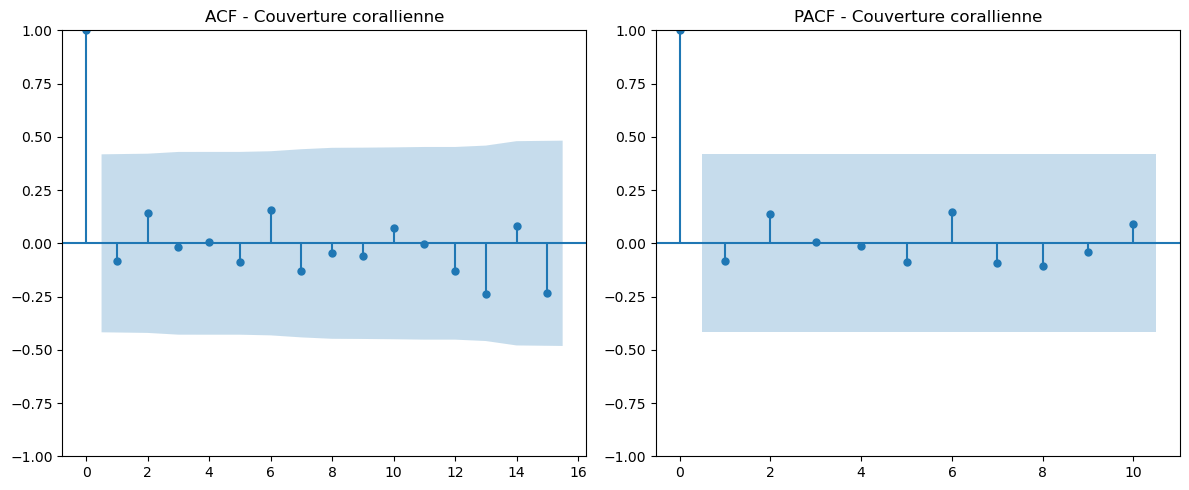

In [6]:
diff_ts = ts['HC'].diff().dropna()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(diff_ts , lags=15, ax=plt.gca())
plt.title("ACF - Couverture corallienne")

# PACF
plt.subplot(1,2,2)
plot_pacf(diff_ts , lags=10, ax=plt.gca(), method='ywm')
plt.title("PACF - Couverture corallienne")

plt.tight_layout()
plt.show()

> Pour la composante AR (Auto-Régressive), nous observons une rupture nette après le **lag 1**, ce qui nous conduit à retenir un ordre **p = 1**.
>
> En revanche, pour la composante MA (Moyenne Mobile), le choix de l’ordre n’est pas aussi évident. Nous devons donc tester plusieurs modèles avec différents ordres q et comparer leurs performances. Nous commençons par un ordre q = 4 pour la première tentative.
>
> Nous entraînons ensuite ce modèle ARIMA sur l’ensemble des données et l’utilisons **pour réaliser des prédictions sur la période 2010–2017**.
> Ces prédictions seront ensuite comparées aux valeurs réelles afin d’évaluer la qualité de notre modèle et son aptitude à reproduire les tendances observées.
>
> Enfin, nous allons afficher **le résumé du modèle** fourni par `statsmodels` ainsi que **le graphique combinant les valeurs réelles et les prédictions** sur la même figure, ce qui permettra une visualisation claire des performances du modèle.

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                     HC   No. Observations:                   23
Model:                 ARIMA(1, 1, 4)   Log Likelihood                 -75.751
Date:                Thu, 19 Mar 2026   AIC                            163.502
Time:                        09:42:42   BIC                            170.048
Sample:                    01-01-1995   HQIC                           165.044
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0943      0.788      0.120      0.905      -1.450       1.638
ma.L1         -0.1780      6.553     -0.027      0.978     -13.022      12.666
ma.L2          0.6056    250.531      0.002      0.9

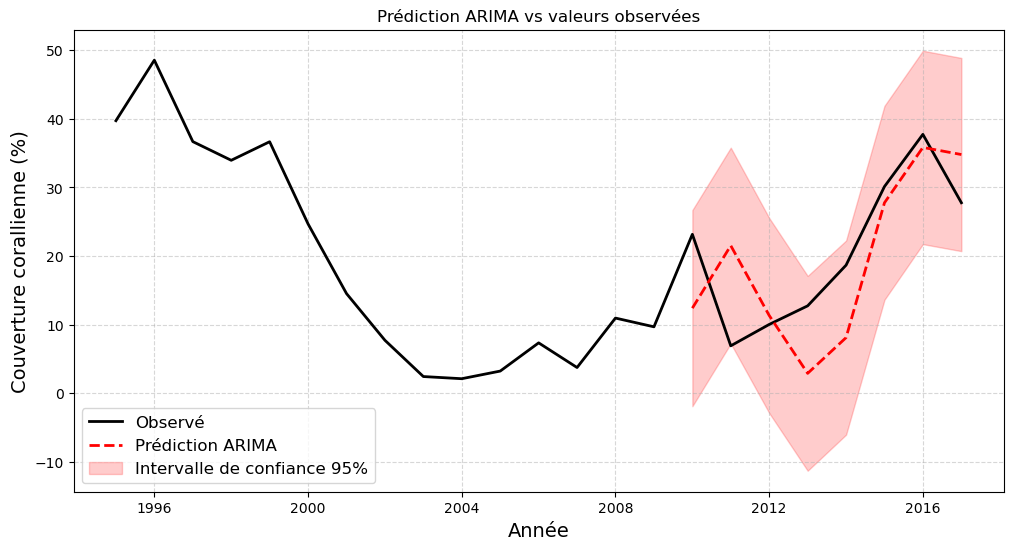

In [7]:
model = ARIMA(ts['HC'], order=(1,1,4))  
model_fit = model.fit()

print(model_fit.summary())

pred = model_fit.predict(start='2010-01-01', end='2017-01-01')
pred = model_fit.get_prediction(start='2010-01-01', end='2017-01-01')
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

plt.figure(figsize=(12,6))

plt.plot(ts['HC'], label='Observé', color='black', linewidth=2)


plt.plot(pred_mean, label='Prédiction ARIMA', color='red', linestyle='--', linewidth=2)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1],
                 color='red', alpha=0.2, label='Intervalle de confiance 95%')


plt.legend(fontsize=12)

plt.title("Prédiction ARIMA vs valeurs observées", fontsize=12)
plt.xlabel("Année", fontsize=14)
plt.ylabel("Couverture corallienne (%)", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

> Le modèle ARIMA(1,1,4) a été ajusté sur les données de **1995 à 2017**.
>
> Les coefficients ne sont pas significatifs individuellement, mais les diagnostics montrent **une série résiduelle proche du bruit blanc** (Prob(Q)=0.92, Prob(JB)=0.76), ce qui suggère un **bon ajustement global**.
>
> Dans le graphique, **les prédictions collent relativement bien aux valeurs réelles, avec un léger décalage dû au lag**, ce qui est attendu pour des prédictions one-step forward.
>
> Pour prédire **plusieurs pas dans le futur**, le modèle utilise à chaque étape les valeurs qu’il a lui-même prédites, ce qui peut aplatir la courbe et rendre les prédictions moins dynamiques. Nous allons illustrer cet effet en générant des prédictions pour 2018–2022, en nous basant uniquement sur les valeurs passées prédites par le modèle.

Prévisions :
2018-01-01    24.964834
2019-01-01    19.947156
2020-01-01    19.439461
2021-01-01    21.989321
2022-01-01    22.229884
Freq: YS-JAN, Name: predicted_mean, dtype: float64

Intervalle de confiance :
             lower HC   upper HC
2018-01-01  10.905064  39.024604
2019-01-01   0.883396  39.010916
2020-01-01  -8.370430  47.249353
2021-01-01 -12.040799  56.019442
2022-01-01 -14.699664  59.159433


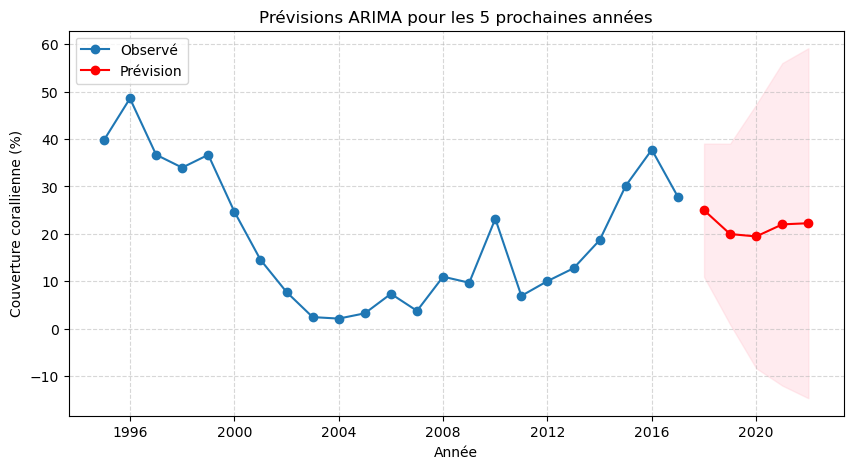

In [8]:
forecast = model_fit.get_forecast(steps=5)

pred_values = forecast.predicted_mean
conf_int = forecast.conf_int()

print("Prévisions :")
print(pred_values)

print("\nIntervalle de confiance :")
print(conf_int)

plt.figure(figsize=(10,5))
plt.plot(ts.index, ts['HC'], marker='o', label='Observé')

future_years = pd.date_range(start=ts.index[-1] + pd.DateOffset(years=1), periods=5, freq='YS')
plt.plot(future_years, pred_values, marker='o', color='red', label='Prévision')

# Intervalle de confiance
plt.fill_between(future_years, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)

plt.xlabel("Année")
plt.ylabel("Couverture corallienne (%)")
plt.title("Prévisions ARIMA pour les 5 prochaines années")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Nous essayons mainteant d'automatiser la démarche en utilisant AUTOARIMA

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=213.485, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=167.624, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=195.969, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=169.588, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=169.599, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=166.352, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=190.589, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=168.342, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=168.346, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=178.367, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.764 seconds
                               SARIMAX Results 

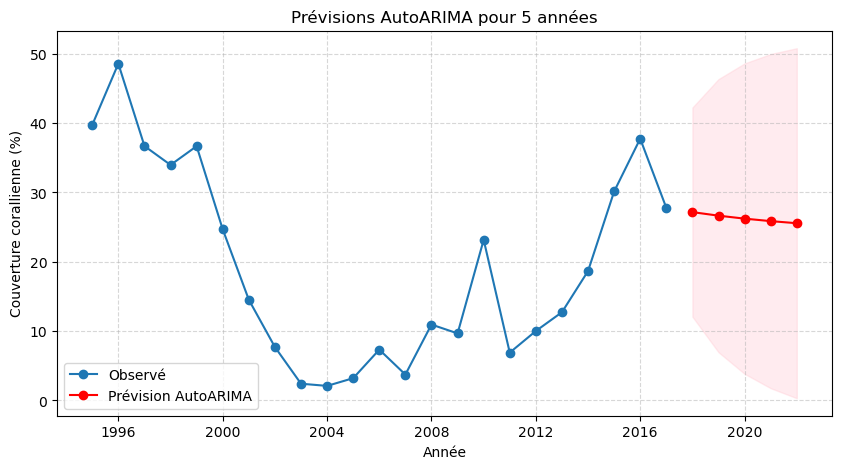

In [9]:
auto_model = auto_arima(
    ts['HC'],
    seasonal=False,       
    stepwise=True,        
    trace=True,           
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())

n_periods = 5
forecast, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)


future_years = pd.date_range(start=ts.index[-1] + pd.DateOffset(years=1), periods=n_periods, freq='YS')

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts.index, ts['HC'], marker='o', label='Observé')
plt.plot(future_years, forecast, marker='o', color='red', label='Prévision AutoARIMA')
plt.fill_between(future_years, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.xlabel("Année")
plt.ylabel("Couverture corallienne (%)")
plt.title("Prévisions AutoARIMA pour 5 années")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

> Nous observons que le modèle AutoARIMA sélectionne des paramètres qui accordent une forte importance à la valeur observée à l’année t pour prédire la couverture corallienne à l’année t+1. Cela indique que la dynamique de la série est fortement dépendante de son état immédiat précédent.
>
# Diagnostic final

> Notre analyse permet d’estimer, pour l’ensemble des récifs appartenant au type de corail **CL4** au sein d’un plateau récifal donné, la couverture corallienne pour l’année suivante. Les résultats montrent que la qualité des prédictions à horizon *t+1* est satisfaisante.
>
> En revanche, les prédictions pour des horizons plus éloignés (*t+2*, *t+3*, etc.) se révèlent nettement moins fiables. Elles deviennent fortement dépendantes des valeurs prédites aux étapes précédentes, ce qui entraîne une accumulation d’erreurs et une perte de précision.
>
> Par ailleurs, cette première analyse présente plusieurs limites importantes :
>
> - Le modèle ne rend pas compte de la spécificité de chaque récif, puisque les données ont été agrégées.
> - Nous n’intégrons pas de variables exogènes, ce qui empêche d’expliquer l’influence de facteurs environnementaux ou anthropiques sur l’évolution de la couverture corallienne.
> - L’approche actuelle ne permet pas de modéliser explicitement les mécanismes écologiques susceptibles d’influencer la dynamique des coraux.
> - L’approche actuelle consiste à créer **un modèle indépendant par cluster et par plateau récifal**, ce qui ne permet pas de tirer parti de l’information disponible sur l’ensemble des clusters, des plateaux et des récifs. Nous voudrions avoir un seul modèle pour l'ensemble des récifs, des coraux et des plateaux. 
>
> Dans les prochains travaux, nous proposerons une analyse plus avancée afin de dépasser ces limitations. L’objectif sera de mieux comprendre comment la couverture corallienne évolue en tenant compte :
>
> - de la diversité des sites de mesure,
> - du type de corail,
> - du plateau récifal,
> - ainsi que des facteurs externes susceptibles d’influencer ces écosystèmes.
>
> Ces améliorations permettront d’obtenir des modèles plus précis et plus informatifs pour comprendre et anticiper l’évolution des récifs coralliens.